In [ ]:
from torch_geometric.data import InMemoryDataset
from torch_geometric.data import Data
from torch_geometric.utils import degree, from_smiles, to_networkx
import shutil, os
import os.path as osp
import torch
import numpy as np
from tqdm import tqdm
# from OGNN.dualgraph.dataset import DGData
# from OGNN.dualgraph.mol import smiles2graphwithface
from rdkit import Chem
from copy import deepcopy
import os
import rdkit
import numpy as np
import pandas as pd
from typing import List
from deepchem.molnet import *
from rdkit import Chem
import csv
import pandas as pd
from dataloader import *
from rdkit.Chem import BRICS
from rdkit.Chem import GetSymmSSSR
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole, MolsToGridImage
from rdkit.Chem import Draw
from rdkit import Chem
import json
from collections import defaultdict
IPythonConsole.drawOptions.addAtomIndices = True

/home/leylazhang/anaconda3/envs/test/lib/python3.8/site-packages/torch_geometric/graphgym/config.py:19: UserWarning: Could not define global config object. Please install 'yacs' via 'pip install yacs' in order to use GraphGym
  warnings.warn("Could not define global config object. Please install "
/home/leylazhang/anaconda3/envs/test/lib/python3.8/site-packages/torch_geometric/graphgym/imports.py:14: UserWarning: Please install 'pytorch_lightning' via  'pip install pytorch_lightning' in order to use GraphGym
  warnings.warn("Please install 'pytorch_lightning' via  "


In [ ]:
import torch
from rdkit import Chem
from rdkit.Chem import BRICS
import networkx as nx
import matplotlib.pyplot as plt
import re


def clean_brics_smiles(smiles):
    """
    Remove `[x*]` markers and empty parentheses `()` from BRICS fragments
    """
    smiles = re.sub(r"\[\d+\*\]", "", smiles)
    smiles = re.sub(r"\(\)", "", smiles)
    return smiles

def brics_fragment_to_indices(mol, brics_smiles):
    """Find the atom indices of a BRICS fragment in the original molecule"""
    cleaned_smiles = clean_brics_smiles(brics_smiles)  # Remove BRICS markers
    frag_mol = Chem.MolFromSmiles(cleaned_smiles)  # Convert to RDKit molecule object
    if frag_mol is None:
        return []

    # Get matching atom indices
    matches = mol.GetSubstructMatches(frag_mol)
    return matches if matches else []


def brics_decomp_with_smiles(mol):
    """
    Perform BRICS decomposition and assign each fragment a unique SMILES and ID,
    while also returning atom index information.
    """
    brics_fragments = list(BRICS.BRICSDecompose(mol, minFragmentSize=2))
    
    # Store fragment information
    cliques = []
    smiles2id = {}
    id2smiles = {}
    fragment_ids = []

    for frag_smiles in brics_fragments:
        
        cleaned_smiles = clean_brics_smiles(frag_smiles)

        # Get all matching indices for the BRICS fragment
        frag_indices = brics_fragment_to_indices(mol, cleaned_smiles)

        # Store all matched fragments
        for indices in frag_indices:  
            cliques.append(list(indices))  # Allow duplicate fragments

        # Assign unique ID
        if cleaned_smiles not in smiles2id:
            smiles2id[cleaned_smiles] = len(smiles2id)
        id_i = smiles2id[cleaned_smiles]
        id2smiles[id_i] = cleaned_smiles
        fragment_ids.append(id_i)

    fragment_ids = torch.tensor(fragment_ids).long()
    return cliques, fragment_ids, smiles2id, id2smiles


def subMol(mol, match):
	
	atoms = set(match) 
	bonds = set() 
	for a in atoms:
		atom = mol.GetAtomWithIdx(a)  
		for b in atom.GetBonds():  
			if b.GetOtherAtomIdx(a) in atoms:  
				bonds.add(b.GetIdx())  
	return Chem.PathToSubmol(mol,list(bonds))  

def sub_to_smiles(mol, atoms): 
	frag = subMol(mol, atoms)
	try:
		Chem.SanitizeMol(frag) 
	except:
		frag = frag  
	if frag is None:  
		frag = subMol(mol, atoms) 
	smiles = Chem.MolToSmiles(frag) 
	return smiles

def is_graph_connected(data): 
    # Convert edge_index to networkx format
    G = nx.Graph() 
    for i in range(data.edge_index.shape[1]): 
        src, dst = data.edge_index[0, i].item(), data.edge_index[1, i].item() 
        G.add_edge(src, dst)  
    for i in range(data.x.shape[0]): 
        G.add_node(i)  

    # Check connectivity
    return nx.is_connected(G)  

bond_type_dict = {
    rdkit.Chem.rdchem.BondType.AROMATIC: 0,  
    rdkit.Chem.rdchem.BondType.SINGLE: 1,   
    rdkit.Chem.rdchem.BondType.DOUBLE: 2,   
    rdkit.Chem.rdchem.BondType.TRIPLE: 3    
}

In [ ]:
motif_edge_attr_dict = {
    'one-bond:1': 1,  
    'one-bond:2': 2,  
}

In [ ]:
%%capture
import warnings
warnings.filterwarnings("ignore")
from collections import defaultdict
from rdkit.Chem import AllChem
from collections import defaultdict

motif_edge_attr_count_dict = defaultdict(int)
motif_edge_attr_count_dict_global = defaultdict(int)

dataset = nNFA_51kDataset()
motif_graph_filename = 'data/DA_Pair_51k/motif_graphs_new.pt'
motif_dict_filename = "data/DA_Pair_51k/motifID2smiles.pt"

smiles2id = {}
id2smiles = {}
motif_graphs = []

for gid, data in enumerate(dataset):
    mol = Chem.MolFromSmiles(data.smiles)
    cliques, fragment_ids, smiles2id, id2smiles = brics_decomp_with_smiles(mol)
    n_motifs = len(cliques)
    motif_x = torch.zeros(n_motifs, 1)
    row = []
    col = []
    motif_edge_attr = []

    # Motif information
    motifs_smiles = []
    motifs_ids = []
    # motif-atom mapping
    atom2motif = defaultdict(list)
    motif2atom = []
    motif2atom_batch = []
    # motif-edge mapping
    motif2edge = []

    me2atom = []
    me2atom_batch = []
    me2edge = []
    me2edge_batch = []
    
    edge2motifedge = torch.ones(data.edge_index.shape[1]).long()*-1
    skip_count = 0
    
    
    for i in range(n_motifs):
        motif_i = cliques[i]
        # smiles_i = sub_to_smiles(mol, motif_i)
        smiles_i = Chem.MolToSmiles(Chem.PathToSubmol(mol, motif_i), canonical=True)
        if smiles_i not in smiles2id:
            smiles2id[smiles_i] = len(smiles2id)
        id_i = smiles2id[smiles_i]
        id2smiles[id_i] = smiles_i    
        motif_x[i] = id_i  
        motif2atom.extend(motif_i)
        motif2atom_batch = motif2atom_batch + [i]*len(motif_i)
        for atom in motif_i:
            atom2motif[atom].append(i)

        # for atom_id, atom in enumerate(motif_i):
        #     bond_id = ((data.edge_index[0]==motif_i[atom_id-1]) & 
        #             (data.edge_index[1]==atom)).nonzero()[0][0].item()
        #     motif2edge.append(bond_id)
        for atom_id in range(1, len(motif_i)):  # from the second atom to the last atom
            curr_atom = motif_i[atom_id]
            prev_atom = motif_i[atom_id-1]
            # check both directions of the edge
            edge_mask = ((data.edge_index[0]==prev_atom) & (data.edge_index[1]==curr_atom)) | \
                    ((data.edge_index[0]==curr_atom) & (data.edge_index[1]==prev_atom))
            edge_indices = edge_mask.nonzero()
            if len(edge_indices) > 0:  # make sure an edge is found
                bond_id = edge_indices[0].item()
                motif2edge.append(bond_id)
    
    motif2edge = torch.tensor(motif2edge).long()
    motif2atom = torch.tensor(motif2atom).long()
    motif2atom_batch = torch.tensor(motif2atom_batch).long()
    
    
    for i in range(n_motifs):
        motif_i = cliques[i]
        for j in range(i+1, n_motifs):
            motif_j = cliques[j]
            common_atoms = list(set(motif_i) & set(motif_j))
            n_common_atoms = len(common_atoms)
            
            if n_common_atoms > 0:  
                row.append(i)
                col.append(j)
                row.append(j)
                col.append(i)
                
                motif_bond_edge_types = []
                for atomid_i in range(n_common_atoms-1):
                    atom_src = common_atoms[atomid_i]
                    for atomid_j in range(atomid_i+1, n_common_atoms):
                        atom_dst = common_atoms[atomid_j]
                        target_edge = ((data.edge_index[0]==atom_src) & 
                                    (data.edge_index[1]==atom_dst)).nonzero()
                        if len(target_edge) == 0:
                            continue
                        else:
                            bond_type = mol.GetBondBetweenAtoms(atom_src,atom_dst).GetBondType()
                            if bond_type not in bond_type_dict:
                                bond_type_dict[bond_type] = len(bond_type_dict)
                            motif_bond_edge_types.append(bond_type_dict[bond_type])
                            edge_id = target_edge[0][0].item()
                            me2edge.append(edge_id)
                            me2edge.append(edge_id)
                            me2edge_batch.append(len(row)-2)
                            me2edge_batch.append(len(row)-1)
                            break

                motif_bond_atom_types = []
                for atom in common_atoms:
                    motif_bond_atom_types.append(mol.GetAtoms()[atom].GetAtomicNum())
                    me2atom.append(atom)
                    me2atom.append(atom)
                    me2atom_batch.append(len(row)-2)
                    me2atom_batch.append(len(row)-1)
                
                motif_bond_atom_types = ",".join([str(x) for x in sorted(motif_bond_atom_types)])
                motif_bond_edge_types = ",".join([str(x) for x in sorted(motif_bond_edge_types)])
                motif_bond_type = f'{motif_bond_atom_types}-{motif_bond_edge_types}'
                
                if motif_bond_type not in motif_edge_attr_dict:
                    motif_edge_attr_dict[motif_bond_type] = len(motif_edge_attr_dict)
                motif_edge_attr.append(motif_edge_attr_dict[motif_bond_type])
                motif_edge_attr.append(motif_edge_attr_dict[motif_bond_type])
                
                motif_edge_attr_count_dict[motif_bond_type] += 1
                motif_edge_attr_count_dict_global[motif_bond_type] += 1
    
    
    visited = set()  
    for i, j in data.edge_index.T.tolist():
        if f'{i}-{j}' in visited or f'{j}-{i}' in visited:
            continue  
        visited.add(f'{i}-{j}') 
        if len(atom2motif[i]) > 1 or len(atom2motif[j]) > 1 or len(atom2motif[i]) == 0 or len(atom2motif[j]) == 0:
            continue  
        motif0 = atom2motif[i][0]  
        motif1 = atom2motif[j][0]  
        if motif0 != motif1:  
            bond_type = mol.GetBondBetweenAtoms(i, j).GetBondType()  
            # only allow single bond connecting motifs --- IGNORE ---
            if bond_type != Chem.rdchem.BondType.SINGLE:
                continue  

            row.append(motif0)  
            col.append(motif1)  
            row.append(motif1)  
            col.append(motif0)  

            if bond_type not in bond_type_dict:
                bond_type_dict[bond_type] = len(bond_type_dict) 

            edge_id = ((data.edge_index[0] == i) & (data.edge_index[1] == j)).nonzero()[0][0].item()  
            me2edge.append(edge_id)  
            me2edge.append(edge_id)  
            me2edge_batch.append(len(row) - 2)  
            me2edge_batch.append(len(row) - 1)  
            me2atom.append(i)  
            me2atom.append(j)  
            me2atom_batch.append(len(row) - 2)  
            me2atom_batch.append(len(row) - 2)  
            me2atom.append(i) 
            me2atom.append(j) 
            me2atom_batch.append(len(row) - 1)  
            me2atom_batch.append(len(row) - 1)  

            motif_bond_type = f'one-bond:{bond_type_dict[bond_type]}'  
            if motif_bond_type not in motif_edge_attr_dict:
                motif_edge_attr_dict[motif_bond_type] = len(motif_edge_attr_dict) 
            motif_edge_attr.append(motif_edge_attr_dict[motif_bond_type])  
            motif_edge_attr.append(motif_edge_attr_dict[motif_bond_type])  
            motif_edge_attr_count_dict[motif_bond_type] += 1  
            motif_edge_attr_count_dict_global[motif_bond_type] += 1 
    
    me2atom = torch.tensor(me2atom).long()
    me2atom_batch = torch.tensor(me2atom_batch).long()
    me2edge = torch.tensor(me2edge).long()
    me2edge_batch = torch.tensor(me2edge_batch).long()
    
    motif_g = Data(
        x=motif_x.reshape(-1,1).long(),
        edge_index=torch.tensor([row, col]),
        edge_attr=torch.tensor(motif_edge_attr).reshape(-1,1).long(),
        motif2atom=motif2atom,
        motif2edge=motif2edge,
        motif2atom_batch=motif2atom_batch,
        me2atom=me2atom,
        me2atom_batch=me2atom_batch,
        me2edge=me2edge,
        me2edge_batch=me2edge_batch
    )

    motif_graphs.append(motif_g)

torch.save(motif_graphs, motif_graph_filename)
with open(motif_dict_filename, "w") as json_file:
    json.dump(id2smiles, json_file)

In [ ]:
### verion4 final
motif_graphs = torch.load('data/DA_Pair_51K/motif_graphs_new.pt')  
new_motif_graphs_filename = 'data/DA_Pair_51K/motif_graphs.pt'
dataset = nNFA_51kDataset()

# Used to count the number of newly added single-bond edges (global statistics)
motif_edge_attr_count_dict = defaultdict(int)

new_motif_graphs = []
multiple_connection_motifs = []
# Fixed key for single-bond attribute
single_bond_key = "one-bond:single"
if single_bond_key not in motif_edge_attr_dict:
    motif_edge_attr_dict[single_bond_key] = len(motif_edge_attr_dict)

for gid in range(len(dataset)):
    # Before processing each graph, reinitialize the connection set
    # to avoid duplicate additions (prevent interference between graphs)
    existing_connections = set()

    # Get the atom-level graph and corresponding motif graph of the current molecule
    data = dataset[gid]        # Atom-level graph (contains data.smiles, data.edge_index, etc.)
    g = motif_graphs[gid]     # Corresponding motif graph

    # =======================
    # Part 2: Directly scan all single-bond edges in the atom graph for supplementation
    # to prevent missing connections caused by BRICS decomposition
    # =======================
    mol = Chem.MolFromSmiles(data.smiles)
    # Build atom-to-motif mapping
    # (if an atom belongs to multiple motifs, use the first one by default)
    atom2motif = defaultdict(list)
    motif2atom_list = g.motif2atom.tolist() if hasattr(g.motif2atom, "tolist") else list(g.motif2atom)
    motif2atom_batch_list = g.motif2atom_batch.tolist() if hasattr(g.motif2atom_batch, "tolist") else list(g.motif2atom_batch)
    for atom, motif_idx in zip(motif2atom_list, motif2atom_batch_list):
        atom2motif[atom].append(motif_idx)
    
    # Iterate over each edge in the atom graph
    for i, j in data.edge_index.T.tolist():
        bond = mol.GetBondBetweenAtoms(i, j)
        # only process existing single bonds
        if not bond or bond.GetBondType() != Chem.rdchem.BondType.SINGLE:
            continue
        if i not in atom2motif or j not in atom2motif:
            continue
        # use the first motif for each atom
        motif_i = atom2motif[i][0]
        motif_j = atom2motif[j][0]
        # Do not add edges if both atoms belong to the same motif
        if motif_i == motif_j:
            continue
        # Define connection tuple to avoid duplicate additions
        connection = (motif_i, motif_j)
        if connection in existing_connections or (motif_j, motif_i) in existing_connections:
            continue
        
        # Construct new edge (add bidirectionally)
        new_edge_index = torch.LongTensor([[motif_i, motif_j],
                                            [motif_j, motif_i]])
        new_edge_attr = torch.LongTensor([motif_edge_attr_dict[single_bond_key],
                                        motif_edge_attr_dict[single_bond_key]]).reshape(-1, 1)
        # Update edge index and edge attributes
        g.edge_index = torch.cat((g.edge_index, new_edge_index), dim=-1)
        g.edge_attr = torch.cat((g.edge_attr, new_edge_attr), dim=0)
        # Record connection to avoid duplication
        existing_connections.add(connection)
        # Update statistics
        motif_edge_attr_count_dict[single_bond_key] += 1

    # =======================
    # Fallback strategy: if the graph is still not connected,
    # directly connect different connected components
    # =======================
    if not is_graph_connected(g):
        # print(f"Graph {gid} is not connected! Applying fallback strategy to connect components.")
        nx_g = to_networkx(g, to_undirected=True)
        comp_list = list(nx.connected_components(nx_g))
        # For each pair of adjacent components, connect representative nodes
        for idx in range(len(comp_list) - 1):
            comp0 = comp_list[idx]
            comp1 = comp_list[idx+1]
            motif0 = list(comp0)[0]
            motif1 = list(comp1)[0]
            new_edge_index = torch.LongTensor([[motif0, motif1],
                                                [motif1, motif0]])
            new_edge_attr = torch.LongTensor([motif_edge_attr_dict[single_bond_key],
                                            motif_edge_attr_dict[single_bond_key]]).reshape(-1, 1)
            g.edge_index = torch.cat((g.edge_index, new_edge_index), dim=-1)
            g.edge_attr = torch.cat((g.edge_attr, new_edge_attr), dim=0)
            existing_connections.add((motif0, motif1))
            motif_edge_attr_count_dict[single_bond_key] += 1
        # Ensure the graph is connected
        assert is_graph_connected(g), f"Graph {gid} is still not connected after fallback!"

    new_motif_graphs.append(g)

torch.save(new_motif_graphs, new_motif_graphs_filename)
print(f"Saved supplemented motif graphs to {new_motif_graphs_filename}")

In [5]:
motif_graphs = torch.load('data/DA_Pair_1.2K/motif_graphs_p.pt') 

In [ ]:
motif_graphs = torch.load('data/DA_Pair_1.2K/motif_graphs_p.pt')

# Assume each motif graph object has an attribute `x` with shape [num_motifs, feature_dim]
num_motifs = [graph.x.size(0) for graph in motif_graphs]
avg_motifs = sum(num_motifs) / len(num_motifs)
print("Average number of motifs per molecule:", avg_motifs)



Average number of motifs per molecule: 13.070892410341951


In [ ]:
import pandas as pd
import torch
from torch_geometric.utils import from_smiles  # assuming this function exists and converts SMILES to graph data format

# read the CSV file (adjust the path as needed)
df = pd.read_csv('data/DA_Pair_51K/raw/NFAs_51K.csv')

n_nodes_list = []
n_edges_list = []
p_nodes_list = []
p_edges_list = []

for row in df.itertuples(index=False):
    n_smiles = row.n_smiles
    p_smiles = row.p_smiles
    try:
        n_data = from_smiles(n_smiles)
        p_data = from_smiles(p_smiles)
        # Assume the converted graph objects have attributes x (node features) and edge_index (edge indices)
        n_nodes_list.append(n_data.x.size(0))
        n_edges_list.append(n_data.edge_index.size(1))
        p_nodes_list.append(p_data.x.size(0))
        p_edges_list.append(p_data.edge_index.size(1))
    except Exception as e:
        print("Error processing molecule:", n_smiles, "or", p_smiles, ":", e)

# calculate average number of nodes and edges for n_smiles and p_smiles
avg_n_nodes = sum(n_nodes_list) / len(n_nodes_list) if n_nodes_list else 0
avg_n_edges = sum(n_edges_list) / len(n_edges_list) if n_edges_list else 0
avg_p_nodes = sum(p_nodes_list) / len(p_nodes_list) if p_nodes_list else 0
avg_p_edges = sum(p_edges_list) / len(p_edges_list) if p_edges_list else 0

print("n_smiles: Avg. #Node: {:.2f}, Avg. #Edge: {:.2f}".format(avg_n_nodes, avg_n_edges))
print("p_smiles: Avg. #Node: {:.2f}, Avg. #Edge: {:.2f}".format(avg_p_nodes, avg_p_edges))


In [6]:
for i, graph in enumerate(motif_graphs):
    print(f"Graph {i} has {graph.x.size(0)} motifs.")
total_motifs = sum(graph.x.size(0) for graph in motif_graphs)
print(f"Total number of motifs across all graphs: {total_motifs}")

# A set to store unique motif identifiers
unique_motifs = set()

# Iterate through each graph and add unique motifs to the set
for i, graph in enumerate(motif_graphs):
    for motif in graph.x.tolist():  # Convert tensor to a list of motifs
        unique_motifs.add(tuple(motif))  # Use tuple to ensure immutability

# Count the total number of unique motifs
total_unique_motifs = len(unique_motifs)
print(f"Total number of unique motifs across all graphs: {total_unique_motifs}")


Graph 0 has 5 motifs.
Graph 1 has 4 motifs.
Graph 2 has 4 motifs.
Graph 3 has 3 motifs.
Graph 4 has 8 motifs.
Graph 5 has 6 motifs.
Graph 6 has 6 motifs.
Graph 7 has 5 motifs.
Graph 8 has 5 motifs.
Graph 9 has 5 motifs.
Graph 10 has 3 motifs.
Graph 11 has 5 motifs.
Graph 12 has 4 motifs.
Graph 13 has 6 motifs.
Graph 14 has 9 motifs.
Graph 15 has 9 motifs.
Graph 16 has 8 motifs.
Graph 17 has 4 motifs.
Graph 18 has 7 motifs.
Graph 19 has 6 motifs.
Graph 20 has 6 motifs.
Graph 21 has 4 motifs.
Graph 22 has 4 motifs.
Graph 23 has 7 motifs.
Graph 24 has 18 motifs.
Graph 25 has 6 motifs.
Graph 26 has 7 motifs.
Graph 27 has 4 motifs.
Graph 28 has 5 motifs.
Graph 29 has 3 motifs.
Graph 30 has 6 motifs.
Graph 31 has 5 motifs.
Graph 32 has 6 motifs.
Graph 33 has 6 motifs.
Graph 34 has 3 motifs.
Graph 35 has 4 motifs.
Graph 36 has 4 motifs.
Graph 37 has 8 motifs.
Graph 38 has 5 motifs.
Graph 39 has 3 motifs.
Graph 40 has 8 motifs.
Graph 41 has 6 motifs.
Graph 42 has 5 motifs.
Graph 43 has 6 motif

In [8]:
max_attr = 0
for graph in motif_graphs:
    try:
        max_temp = graph.edge_attr.max().item()
    except:
        continue
    if max_temp > max_attr:
        max_attr = max_temp
print(max_attr)

3


In [9]:
motif_graphs[0].edge_index

tensor([[1, 3, 2, 4, 1, 0, 0, 2, 0, 5],
        [3, 1, 4, 2, 0, 1, 2, 0, 5, 0]])

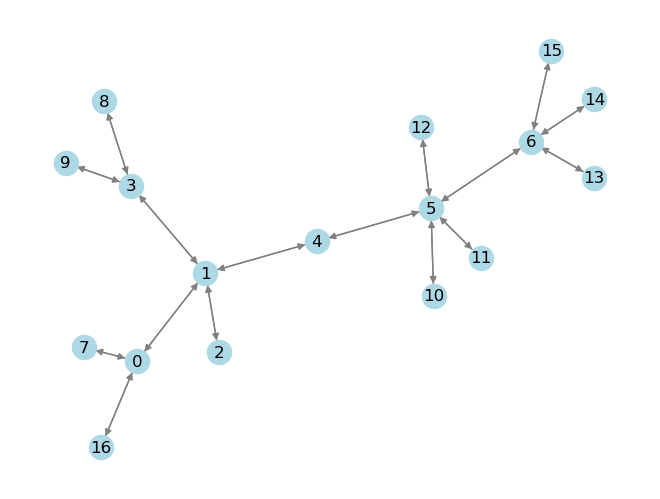

In [ ]:
import torch
import networkx as nx
import matplotlib.pyplot as plt

# Convert edge_index representation to a NetworkX graph
edge_index = torch.tensor([[ 7,  0,  0,  1,  1,  2,  1,  3,  3,  8,  3,  9,  1,  4,  4,  5,  5, 10,
        5, 11,  5, 12,  5,  6,  6, 13,  6, 14,  6, 15,  0, 16],
                        [ 0,  7,  1,  0,  2,  1,  3,  1,  8,  3,  9,  3,  4,  1,  5,  4, 10,  5,
        11,  5, 12,  5,  6,  5, 13,  6, 14,  6, 15,  6, 16,  0]])
G = nx.DiGraph()  # Directed graph
G.add_edges_from(edge_index.t().tolist())

# Draw the graph
nx.draw(G, with_labels=True, node_color="lightblue", edge_color="gray")
plt.show()


In [11]:
motif_graphs[0]
# print(motif_graphs[4].x)

Data(x=[6, 1], edge_index=[2, 10], edge_attr=[10, 1], motif2atom=[46], motif2edge=[39], motif2atom_batch=[46], me2atom=[20], me2atom_batch=[20], me2edge=[16], me2edge_batch=[16])

In [12]:
motif_graphs[600].motif2atom

tensor([27, 28, 29, 30, 36, 37, 38, 39, 40, 23, 24, 25, 26, 41, 31, 32, 33, 34,
        35, 23, 24, 25, 26, 41, 31, 32, 33, 34, 35,  8,  7,  6,  5,  4,  3,  2,
         1,  0,  9, 10, 11, 12, 13, 14, 15, 16])

In [ ]:
import torch
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import networkx as nx

def plot_motif_graph(data):
    # Convert edge_index to networkx format
    G = nx.Graph()
    for i in range(data.edge_index.shape[1]):
        src, dst = data.edge_index[0, i].item(), data.edge_index[1, i].item()
        edge_type = data.edge_attr[i].item()
        G.add_edge(src, dst, edge_type=edge_type)
    for i in range(data.x.shape[0]):
        G.add_node(i)

    pos = nx.spring_layout(G)  # Choose a layout for the nodes

    edge_colors = [G[src][dst]["edge_type"] for src, dst in G.edges()]
    plt.figure(facecolor="white")
    # Plot nodes with their IDs as labels
    nx.draw_networkx_nodes(G, pos, node_size=200, cmap="viridis", node_color='white', edgecolors='black')
    # labels = {i: str(data.x[i].long().item()) for i in range(len(data.x))}
    # # Create a dictionary mapping node indices to labels
    
    labels = {i: str(data.x[i].long().item()) for i in range(len(data.x))}
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color="black")

    # Plot edges with different colors based on edge_type
    nx.draw_networkx_edges(G, pos, width=5.0, edge_color=edge_colors, edge_cmap=plt.cm.Set3)

    plt.axis("off")
    plt.show()

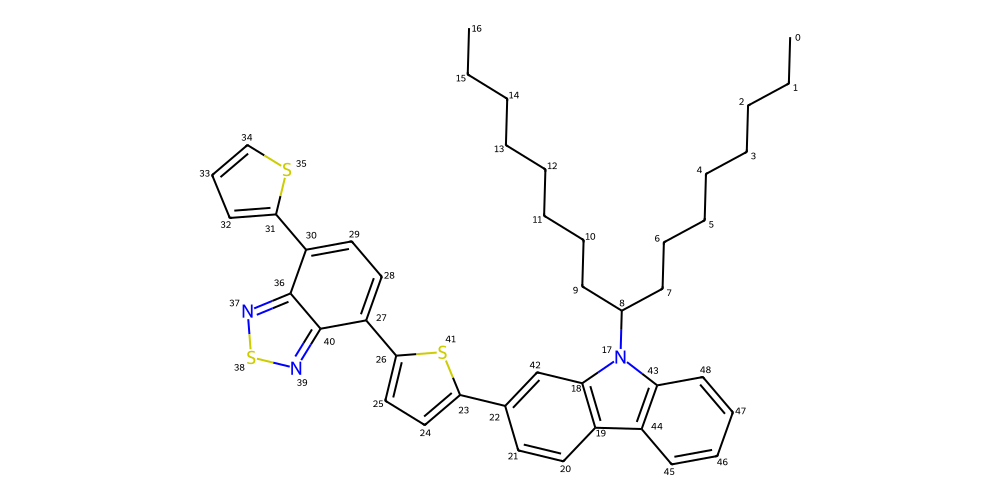

In [14]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole, MolsToGridImage
from rdkit.Chem import Draw
IPythonConsole.drawOptions.addAtomIndices = True
dos = Draw.MolDrawOptions()
dos.addAtomIndices=True
# Draw.MolToImage(Chem.MolFromSmiles(dataset.smiles[i]),size= (500,500), fitImage=True, options=dos)
Draw.MolToImage(Chem.MolFromSmiles(dataset.smiles[600]),size= (1000,500), fitImage=True, options=dos)


In [15]:
print(dataset.smiles[15])

CCCCCCCCC(CCCCCCCC)N(C1=C2C=CC(C3=CC=C(C4=CC=C(C5=CC=CS5)C6=NSN=C46)S3)=C1)C7=C2C=CC=C7


In [16]:
print(motif_graphs[600].x)

tensor([[4],
        [5],
        [6],
        [5],
        [6],
        [7]])


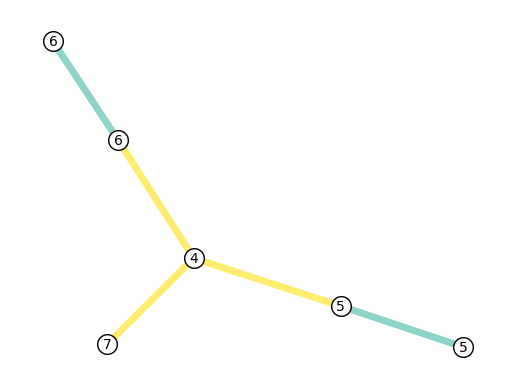

In [18]:
plot_motif_graph(motif_graphs[20000])